In [2]:
import yaml

yaml_path = "/kaggle/input/7-defect-dataset/data.yaml"  # <-- তোমার dataset এর path দিবে

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("Number of classes:", data["nc"])
print("Original class names:", data["names"])


Number of classes: 7
Original class names: ['baekra', 'color issues', 'contamination', 'cut', 'gray stitch', 'selvet', 'stain']


✅ Number of classes: 7
✅ Class names: ['baekra', 'color issues', 'contamination', 'cut', 'gray stitch', 'selvet', 'stain']

📂 Dataset split counts:
train: 1950 images
valid: 562 images
test: 280 images


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


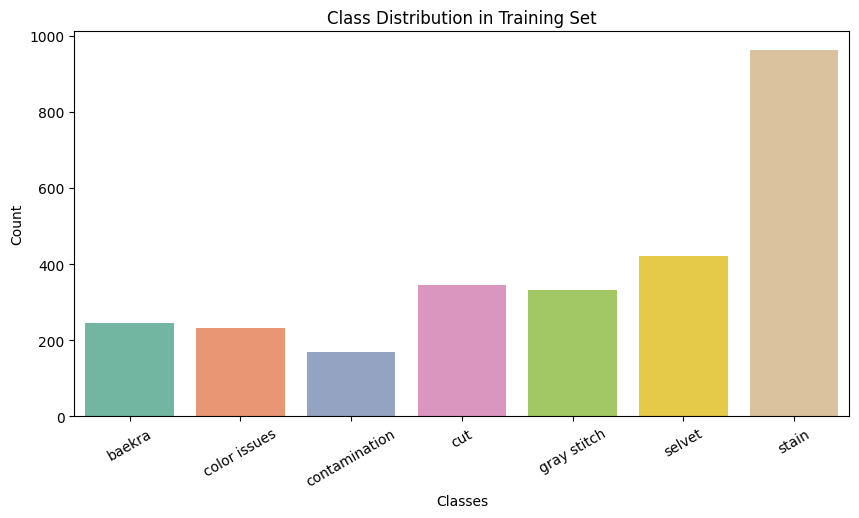

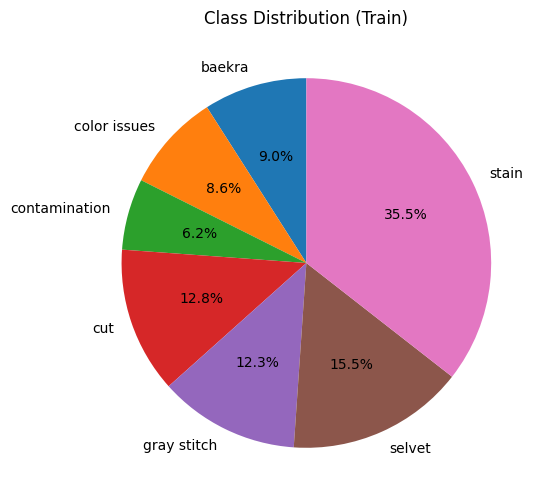

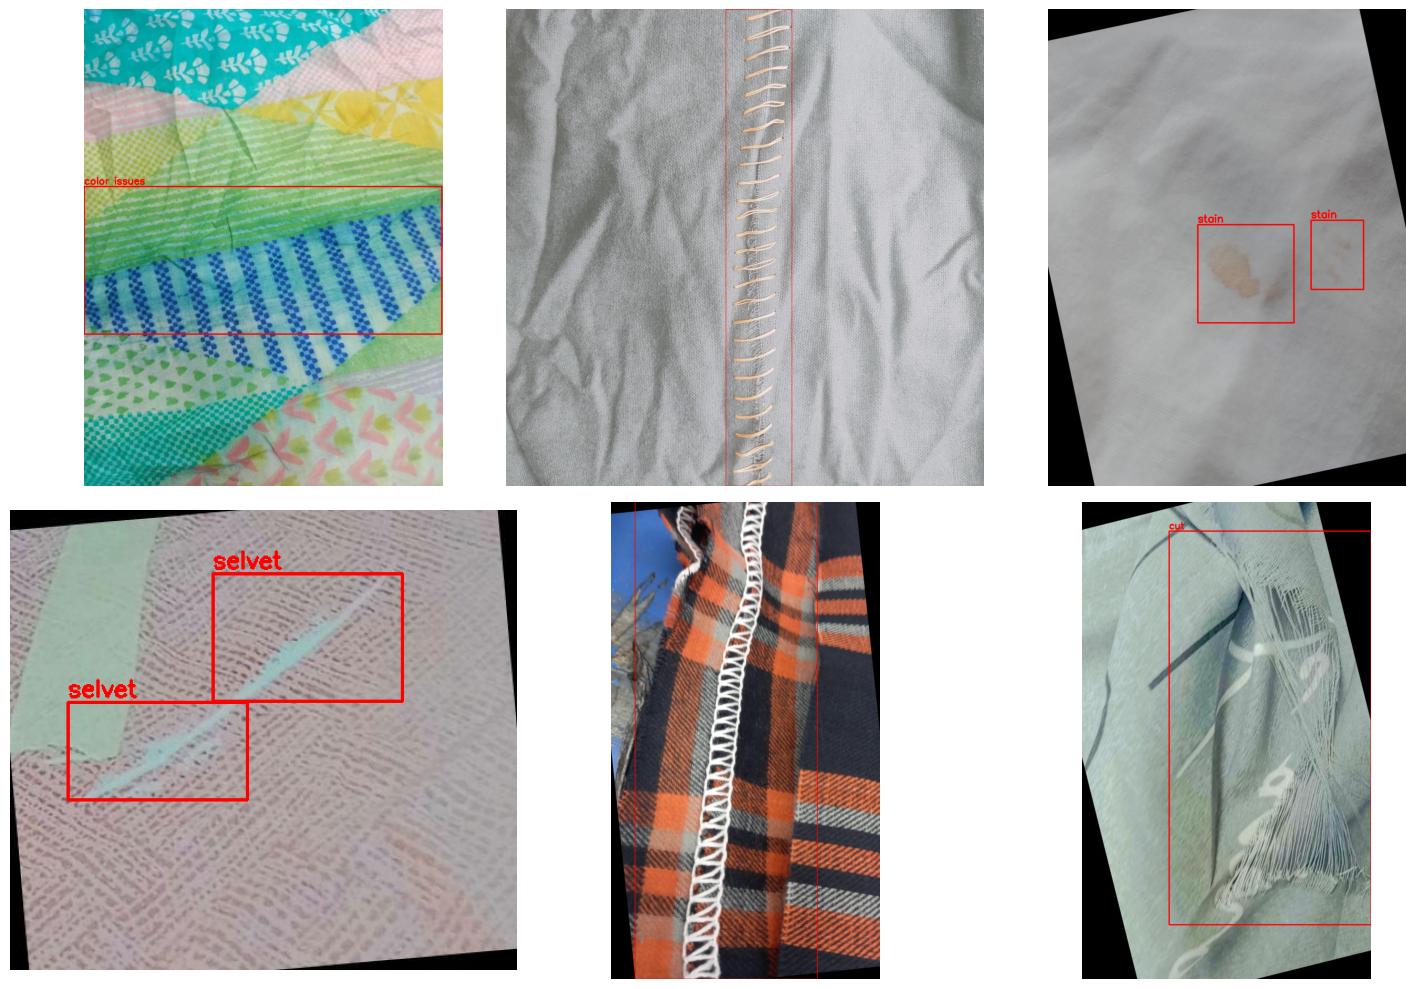

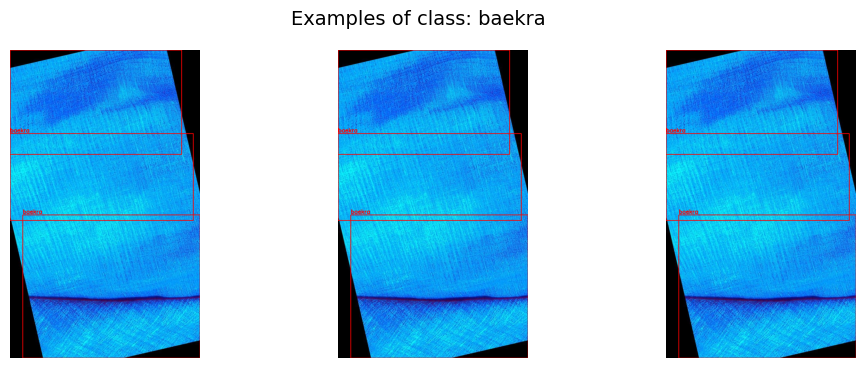

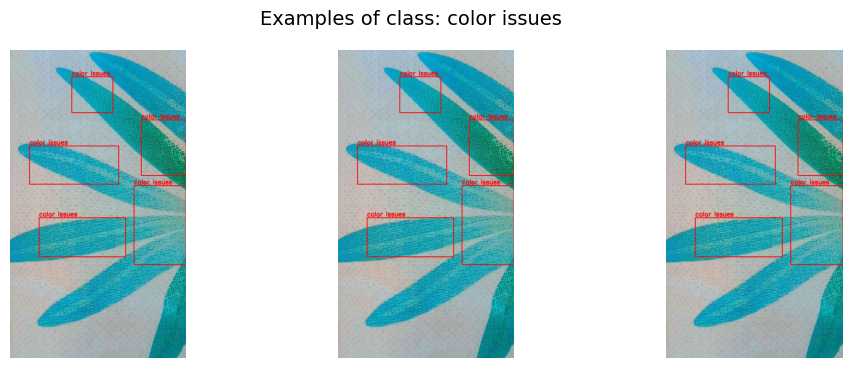

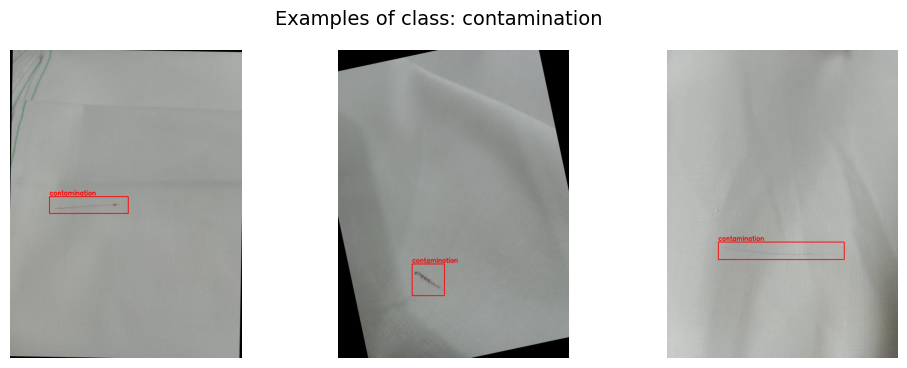

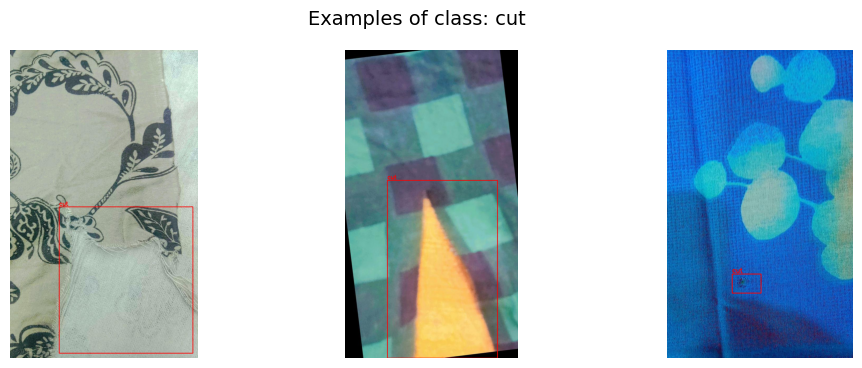

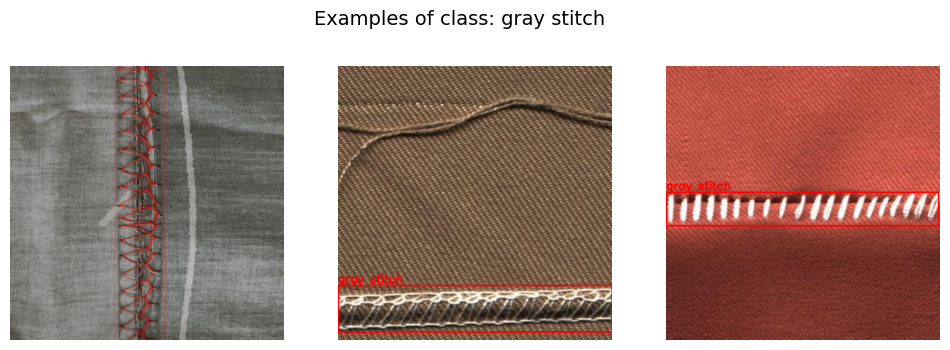

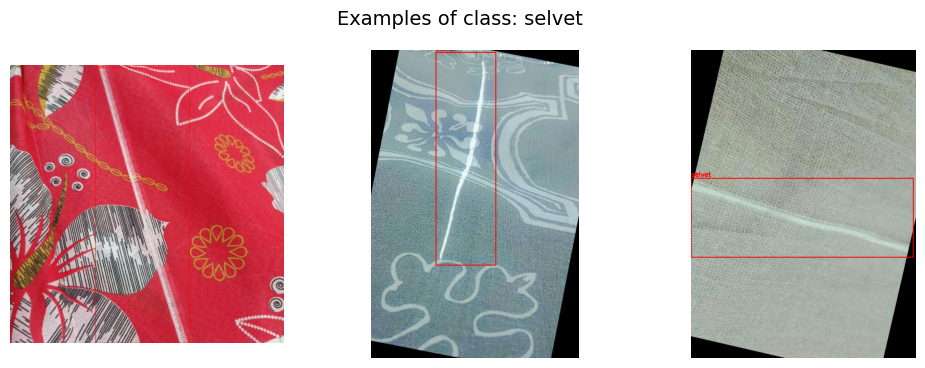

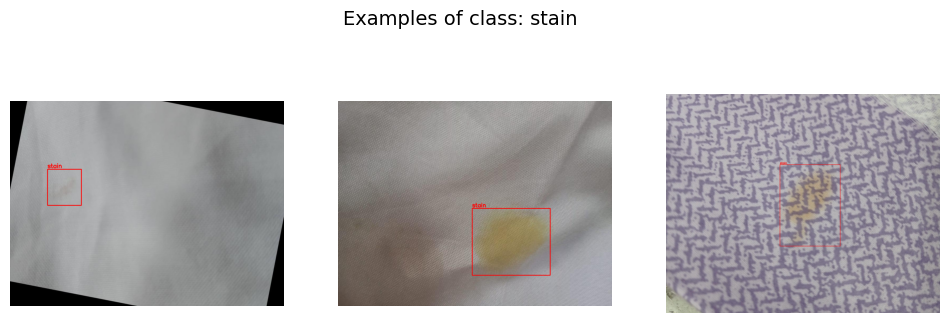

In [3]:
# --------------------------
# 📊 Dataset EDA & Visualization
# --------------------------
import os
import random
import yaml
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# ✅ Path
DATASET_PATH = "/kaggle/input/7-defect-dataset"

# --------------------------
# 1. Load class names
# --------------------------
yaml_path = os.path.join(DATASET_PATH, "data.yaml")
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml["names"]
num_classes = data_yaml["nc"]

print("✅ Number of classes:", num_classes)
print("✅ Class names:", class_names)

# --------------------------
# 2. Count images in splits
# --------------------------
splits = ["train", "valid", "test"]
split_counts = {}

for split in splits:
    img_path = os.path.join(DATASET_PATH, split, "images")
    images = glob(os.path.join(img_path, "*.jpg")) + glob(os.path.join(img_path, "*.png"))
    split_counts[split] = len(images)

print("\n📂 Dataset split counts:")
for k,v in split_counts.items():
    print(f"{k}: {v} images")

# --------------------------
# 3. Class distribution
# --------------------------
def get_class_distribution(label_dir):
    counts = {cls: 0 for cls in class_names}
    label_files = glob(os.path.join(label_dir, "*.txt"))

    for file in label_files:
        with open(file, "r") as f:
            lines = f.readlines()
            for line in lines:
                cls_id = int(line.split()[0])
                counts[class_names[cls_id]] += 1
    return counts

train_label_dir = os.path.join(DATASET_PATH, "train", "labels")
train_counts = get_class_distribution(train_label_dir)

# 📊 Plot distribution
plt.figure(figsize=(10,5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette="Set2")
plt.xticks(rotation=30)
plt.title("Class Distribution in Training Set")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(train_counts.values(), labels=train_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title("Class Distribution (Train)")
plt.show()

# --------------------------
# 4. Visualize random samples with bboxes
# --------------------------
def plot_image_with_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x, y, bw, bh = map(float, line.strip().split())
                cls = int(cls)

                # YOLO format → pixel values
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                # Draw box
                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
                cv2.putText(img, class_names[cls], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

    plt.imshow(img)
    plt.axis("off")

# Show random 6 samples
train_img_dir = os.path.join(DATASET_PATH, "train", "images")
train_lbl_dir = os.path.join(DATASET_PATH, "train", "labels")
train_images = glob(os.path.join(train_img_dir, "*.jpg"))

plt.figure(figsize=(15,10))
for i in range(6):
    idx = random.randint(0, len(train_images)-1)
    img_path = train_images[idx]
    lbl_path = os.path.join(train_lbl_dir, os.path.basename(img_path).replace(".jpg", ".txt"))
    plt.subplot(2,3,i+1)
    plot_image_with_boxes(img_path, lbl_path)
plt.tight_layout()
plt.show()

# --------------------------
# 5. Show class-wise examples
# --------------------------
def show_class_examples(class_id, num_samples=3):
    """Show sample images for a given class"""
    examples = []
    label_files = glob(os.path.join(train_lbl_dir, "*.txt"))

    for file in label_files:
        with open(file, "r") as f:
            for line in f.readlines():
                cls = int(line.split()[0])
                if cls == class_id:
                    img_file = file.replace("labels", "images").replace(".txt", ".jpg")
                    if os.path.exists(img_file):
                        examples.append(img_file)
    plt.figure(figsize=(12,4))
    for i, img_path in enumerate(examples[:num_samples]):
        plt.subplot(1, num_samples, i+1)
        plot_image_with_boxes(img_path, img_path.replace("images", "labels").replace(".jpg", ".txt"))
    plt.suptitle(f"Examples of class: {class_names[class_id]}", fontsize=14)
    plt.show()

# Example: show few classes
for cid in range(num_classes):
    show_class_examples(cid, num_samples=3)


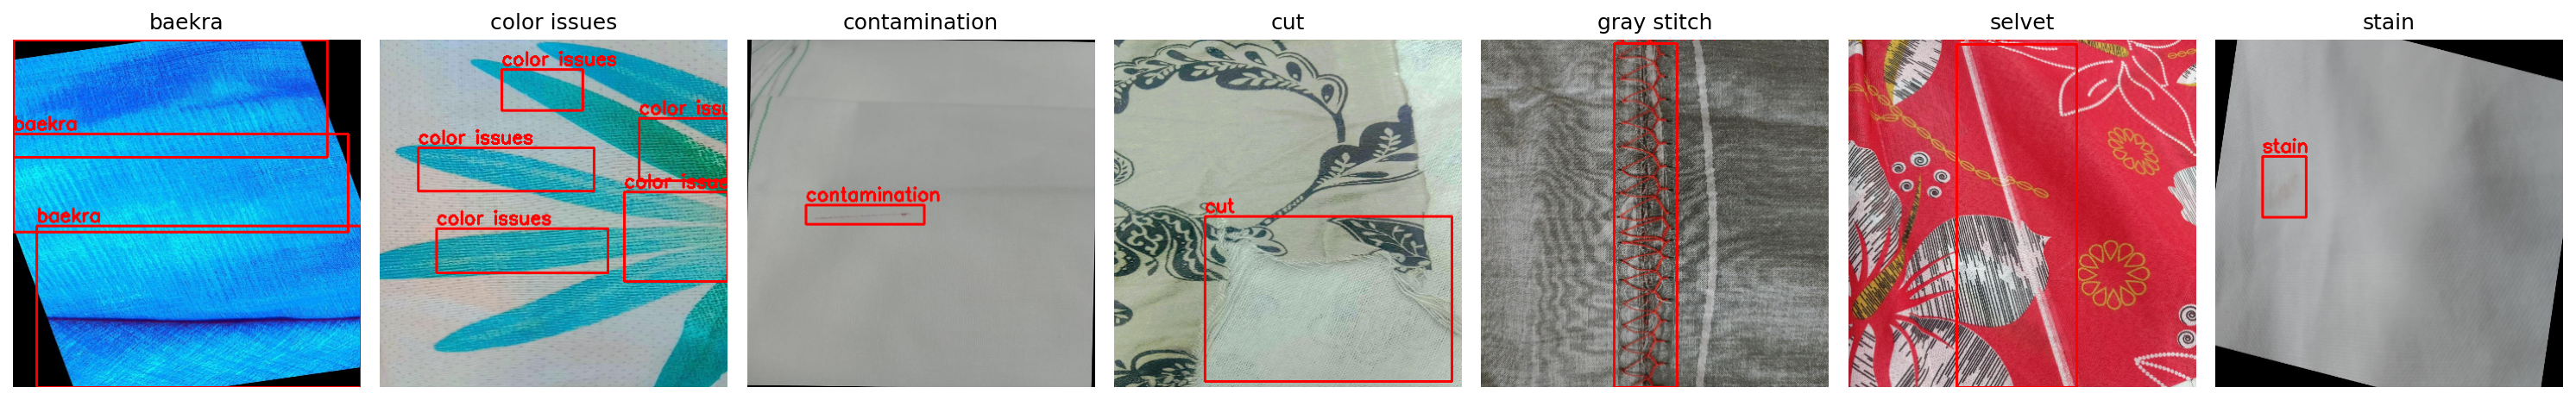

In [5]:
# --------------------------
# Show one sample per class, same size, high DPI
# --------------------------
import matplotlib.pyplot as plt
import cv2

# Parameters
TARGET_SIZE = (400, 400)  # Width x Height for all images
DPI = 150

plt.figure(figsize=(20,6), dpi=DPI)

for cid in range(num_classes):
    # Find one example image for this class
    label_files = glob(os.path.join(train_lbl_dir, "*.txt"))
    example_img = None
    for file in label_files:
        with open(file, "r") as f:
            lines = f.readlines()
            if any(int(line.split()[0]) == cid for line in lines):
                img_file = file.replace("labels", "images").replace(".txt", ".jpg")
                if os.path.exists(img_file):
                    example_img = img_file
                    break
    if example_img is None:
        continue

    # Load and resize image
    img = cv2.imread(example_img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, TARGET_SIZE)

    # Draw bounding boxes for this class only
    lbl_file = example_img.replace("images", "labels").replace(".jpg", ".txt")
    if os.path.exists(lbl_file):
        h, w = TARGET_SIZE[1], TARGET_SIZE[0]
        with open(lbl_file, "r") as f:
            for line in f.readlines():
                cls, x, y, bw, bh = map(float, line.strip().split())
                cls = int(cls)
                if cls != cid:
                    continue  # Only draw bbox for this class
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
                cv2.putText(img, class_names[cls], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

    plt.subplot(2, 7, cid+1)
    plt.imshow(img)
    plt.title(class_names[cid])
    plt.axis("off")

plt.tight_layout()
plt.show()


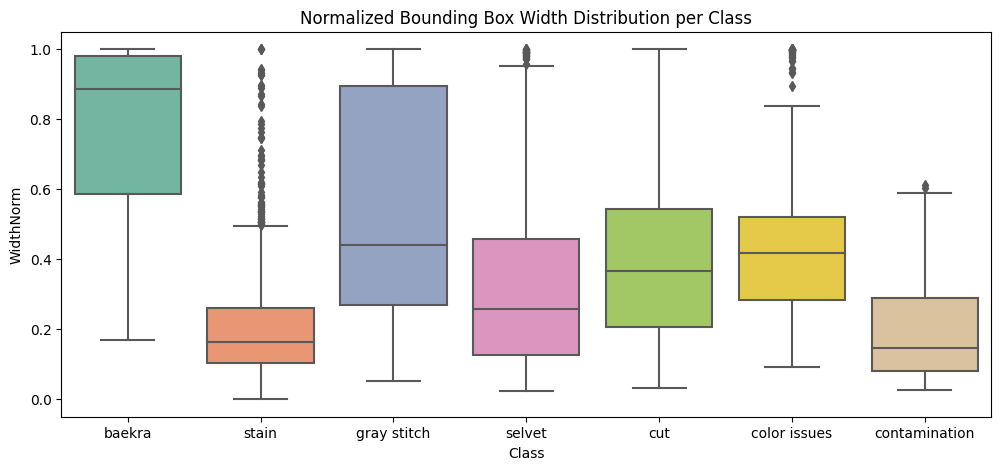

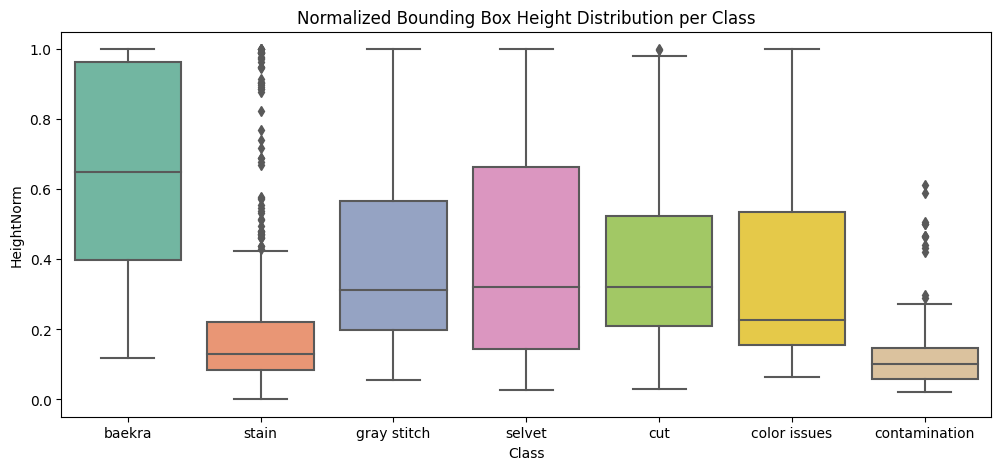

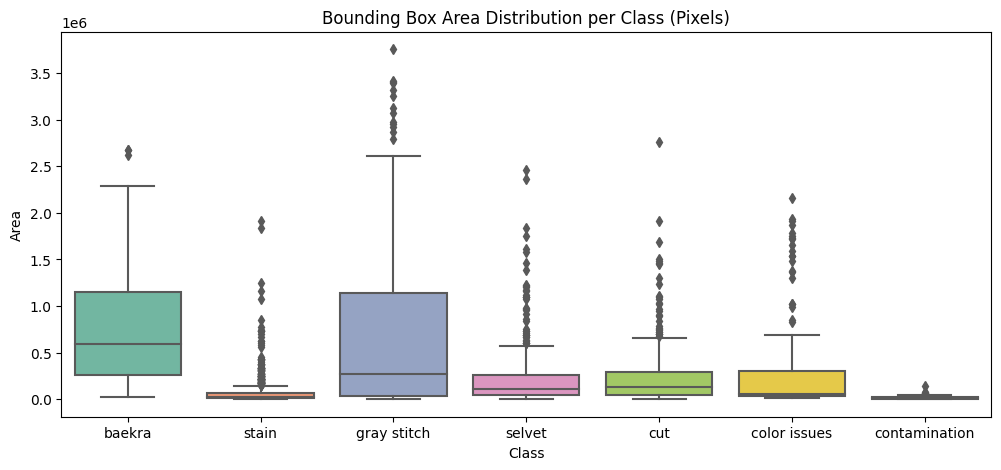

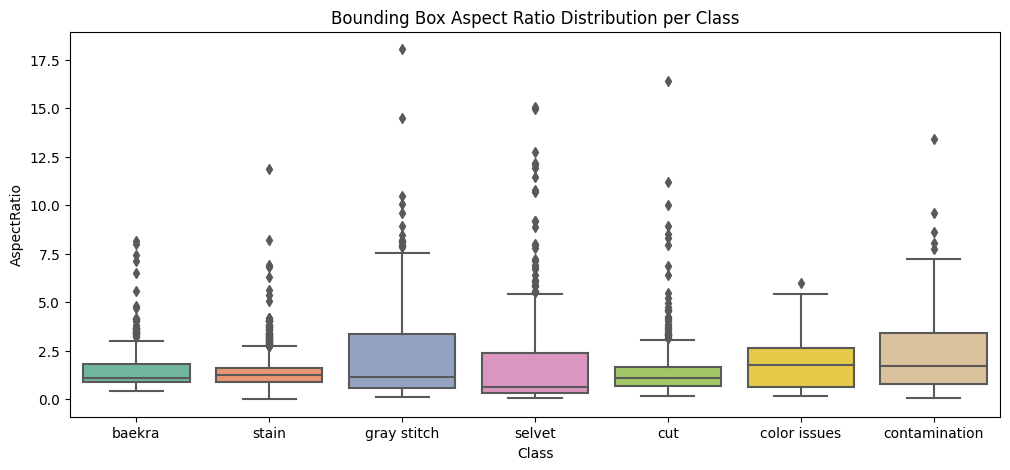

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


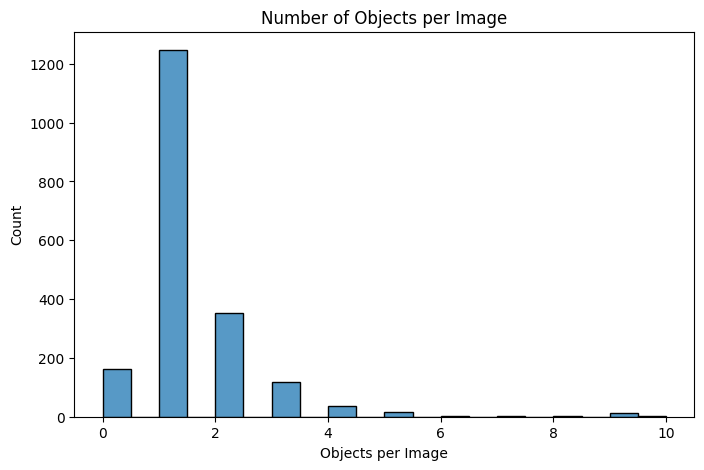

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


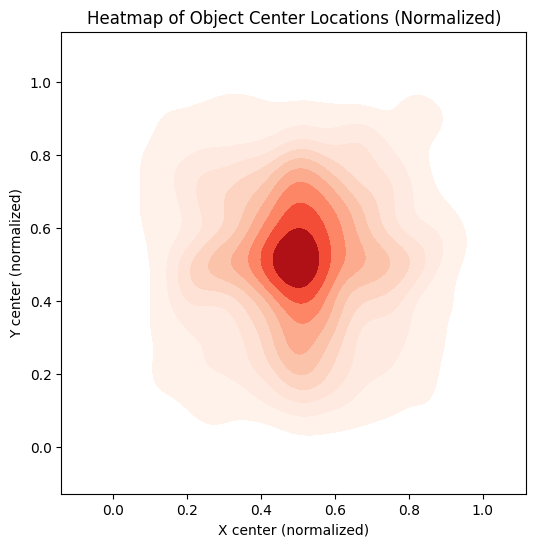

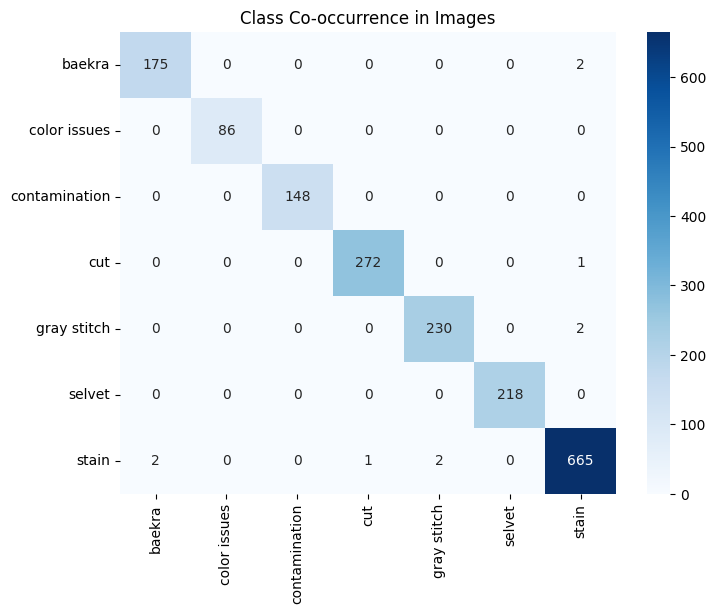

In [6]:
# --------------------------
# Advanced YOLO Dataset Visualizations
# --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from glob import glob
import os

# Paths
train_img_dir = os.path.join(DATASET_PATH, "train", "images")
train_lbl_dir = os.path.join(DATASET_PATH, "train", "labels")

# --------------------------
# 1. Bounding box statistics
# --------------------------
bbox_data = []
label_files = glob(os.path.join(train_lbl_dir, "*.txt"))

for lbl_file in label_files:
    img_file = lbl_file.replace("labels", "images").replace(".txt", ".jpg")
    if not os.path.exists(img_file):
        continue
    img = cv2.imread(img_file)
    h_img, w_img, _ = img.shape
    with open(lbl_file, "r") as f:
        for line in f.readlines():
            cls, x, y, bw, bh = map(float, line.strip().split())
            x1 = (x - bw/2) * w_img
            y1 = (y - bh/2) * h_img
            x2 = (x + bw/2) * w_img
            y2 = (y + bh/2) * h_img
            area = (x2 - x1) * (y2 - y1)
            bbox_data.append([class_names[int(cls)], bw, bh, area])

bbox_df = pd.DataFrame(bbox_data, columns=["Class", "WidthNorm", "HeightNorm", "Area"])

# --------------------------
# 2. Bounding box size distribution per class
# --------------------------
plt.figure(figsize=(12,5))
sns.boxplot(x="Class", y="WidthNorm", data=bbox_df, palette="Set2")
plt.title("Normalized Bounding Box Width Distribution per Class")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x="Class", y="HeightNorm", data=bbox_df, palette="Set2")
plt.title("Normalized Bounding Box Height Distribution per Class")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x="Class", y="Area", data=bbox_df, palette="Set2")
plt.title("Bounding Box Area Distribution per Class (Pixels)")
plt.show()

# --------------------------
# 3. Aspect ratio (Width/Height) per class
# --------------------------
bbox_df["AspectRatio"] = bbox_df["WidthNorm"] / bbox_df["HeightNorm"]
plt.figure(figsize=(12,5))
sns.boxplot(x="Class", y="AspectRatio", data=bbox_df, palette="Set2")
plt.title("Bounding Box Aspect Ratio Distribution per Class")
plt.show()

# --------------------------
# 4. Number of objects per image
# --------------------------
obj_count = []
for lbl_file in label_files:
    with open(lbl_file, "r") as f:
        count = len(f.readlines())
        obj_count.append(count)

plt.figure(figsize=(8,5))
sns.histplot(obj_count, bins=20, kde=False)
plt.title("Number of Objects per Image")
plt.xlabel("Objects per Image")
plt.ylabel("Count")
plt.show()

# --------------------------
# 5. Heatmap of object locations (relative x,y center)
# --------------------------
plt.figure(figsize=(6,6))
x_centers = []
y_centers = []
for lbl_file in label_files:
    with open(lbl_file, "r") as f:
        for line in f.readlines():
            cls, x, y, bw, bh = map(float, line.strip().split())
            x_centers.append(x)
            y_centers.append(y)

sns.kdeplot(x=x_centers, y=y_centers, fill=True, cmap="Reds")
plt.title("Heatmap of Object Center Locations (Normalized)")
plt.xlabel("X center (normalized)")
plt.ylabel("Y center (normalized)")
plt.show()

# --------------------------
# 6. Pairwise class co-occurrence
# --------------------------
co_occurrence = pd.DataFrame(0, index=class_names, columns=class_names)
for lbl_file in label_files:
    with open(lbl_file, "r") as f:
        classes_in_image = set(int(line.split()[0]) for line in f.readlines())
        for c1 in classes_in_image:
            for c2 in classes_in_image:
                co_occurrence.iloc[c1, c2] += 1

plt.figure(figsize=(8,6))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="Blues")
plt.title("Class Co-occurrence in Images")
plt.show()


🎯 Advanced Dataset Visualization Suite
✅ Classes: 7
✅ Defect Types: ['baekra', 'color issues', 'contamination', 'cut', 'gray stitch', 'selvet', 'stain']


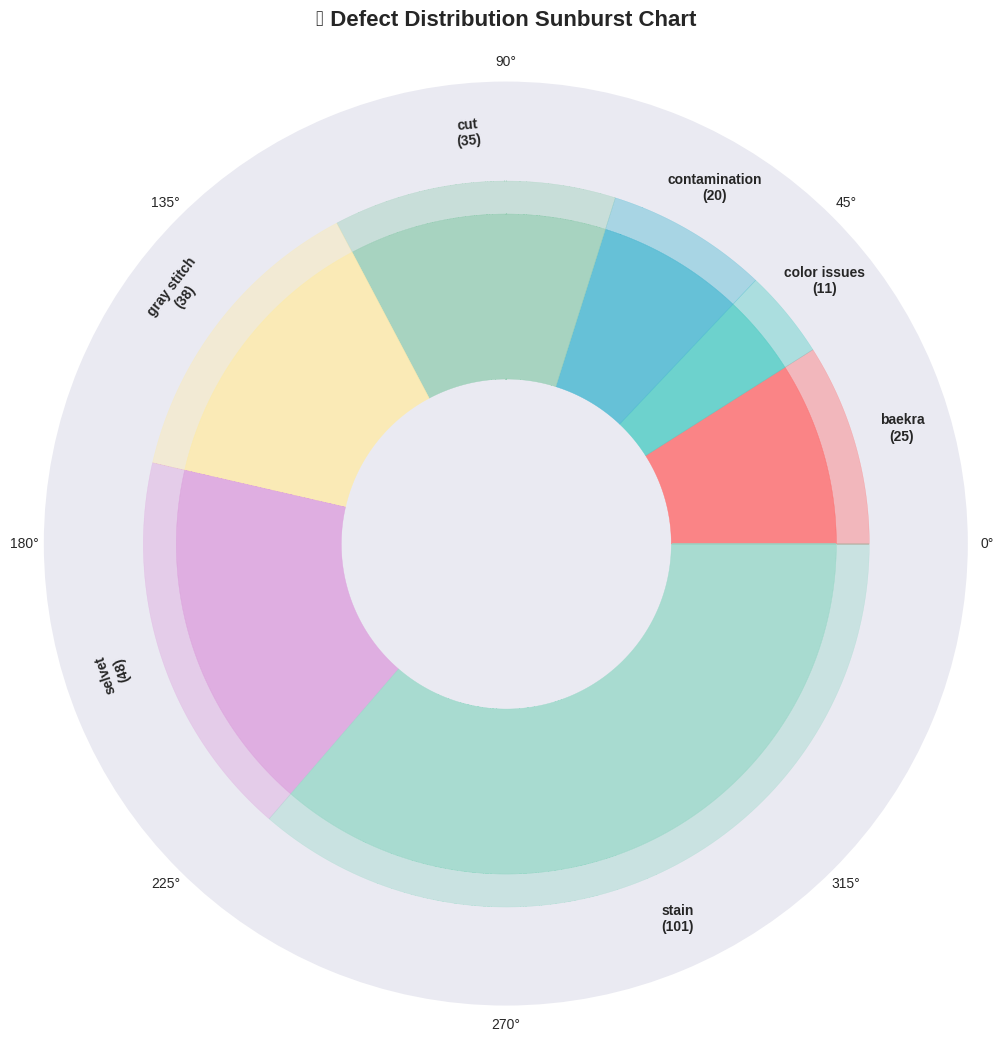

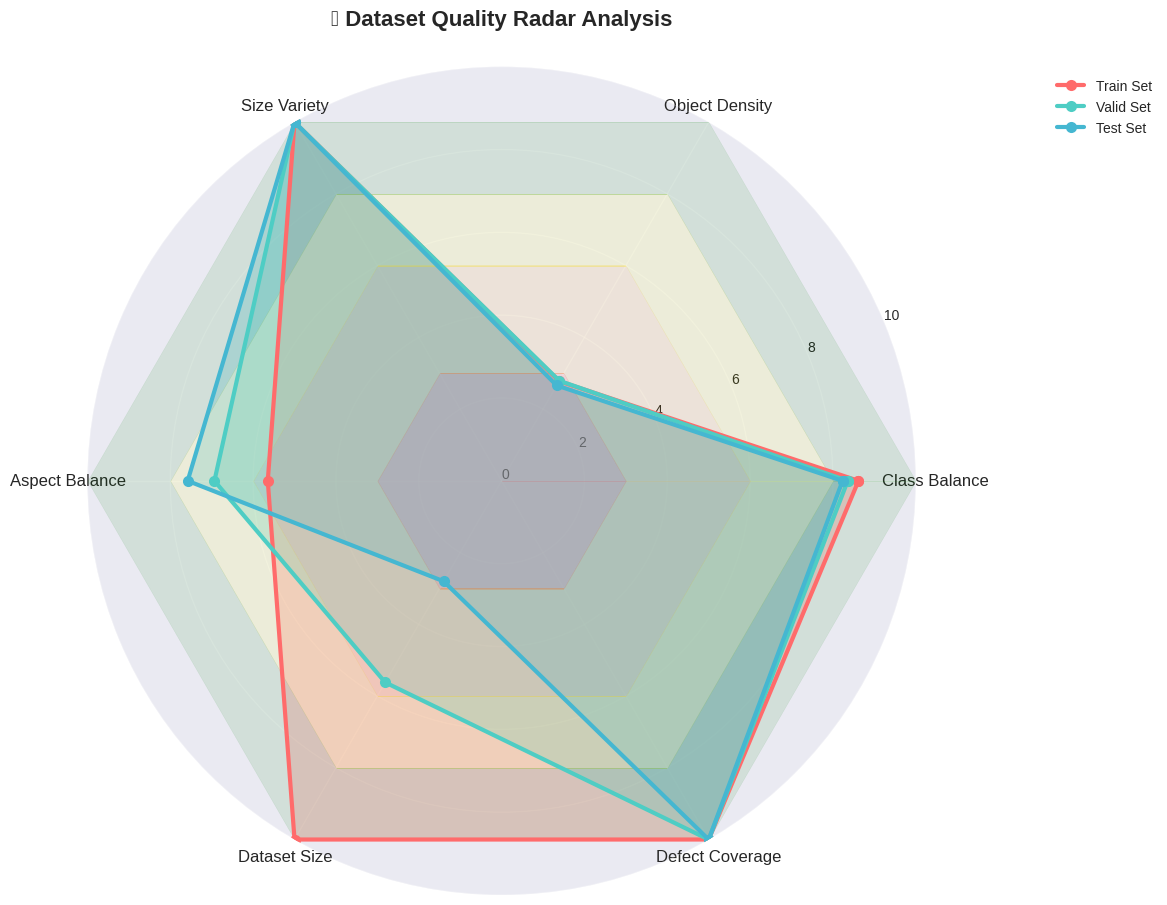

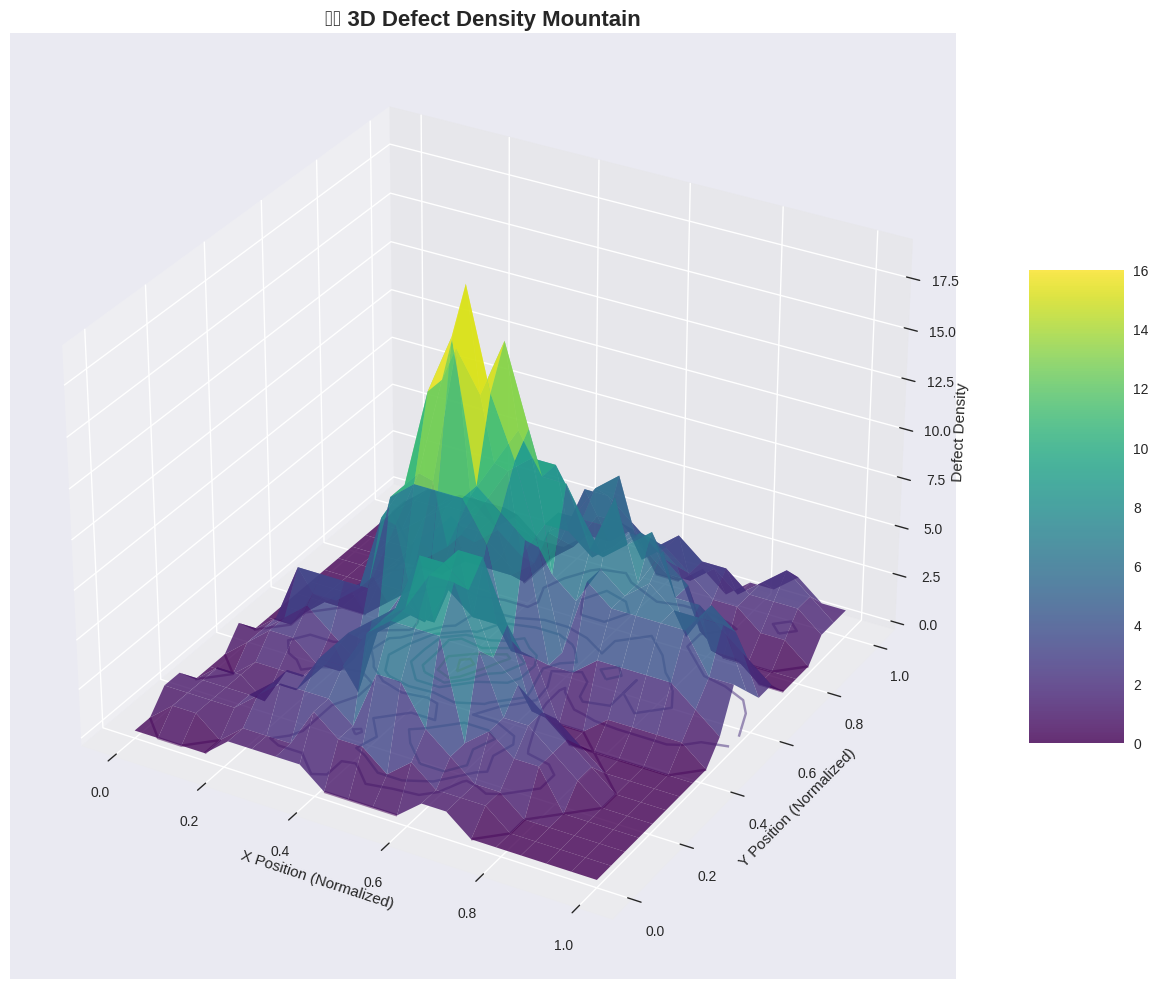

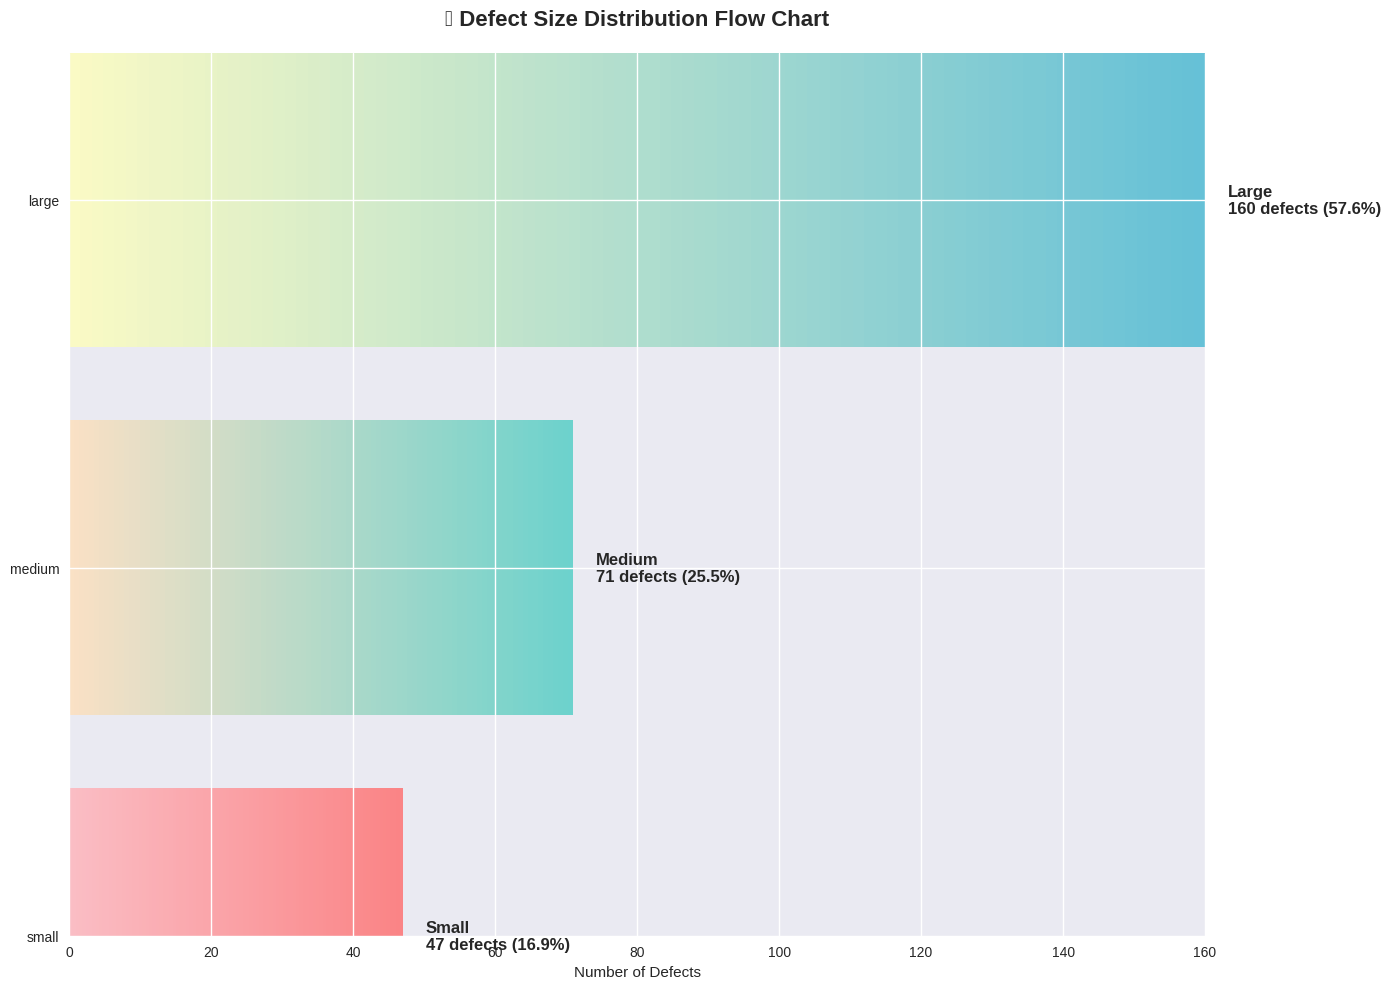

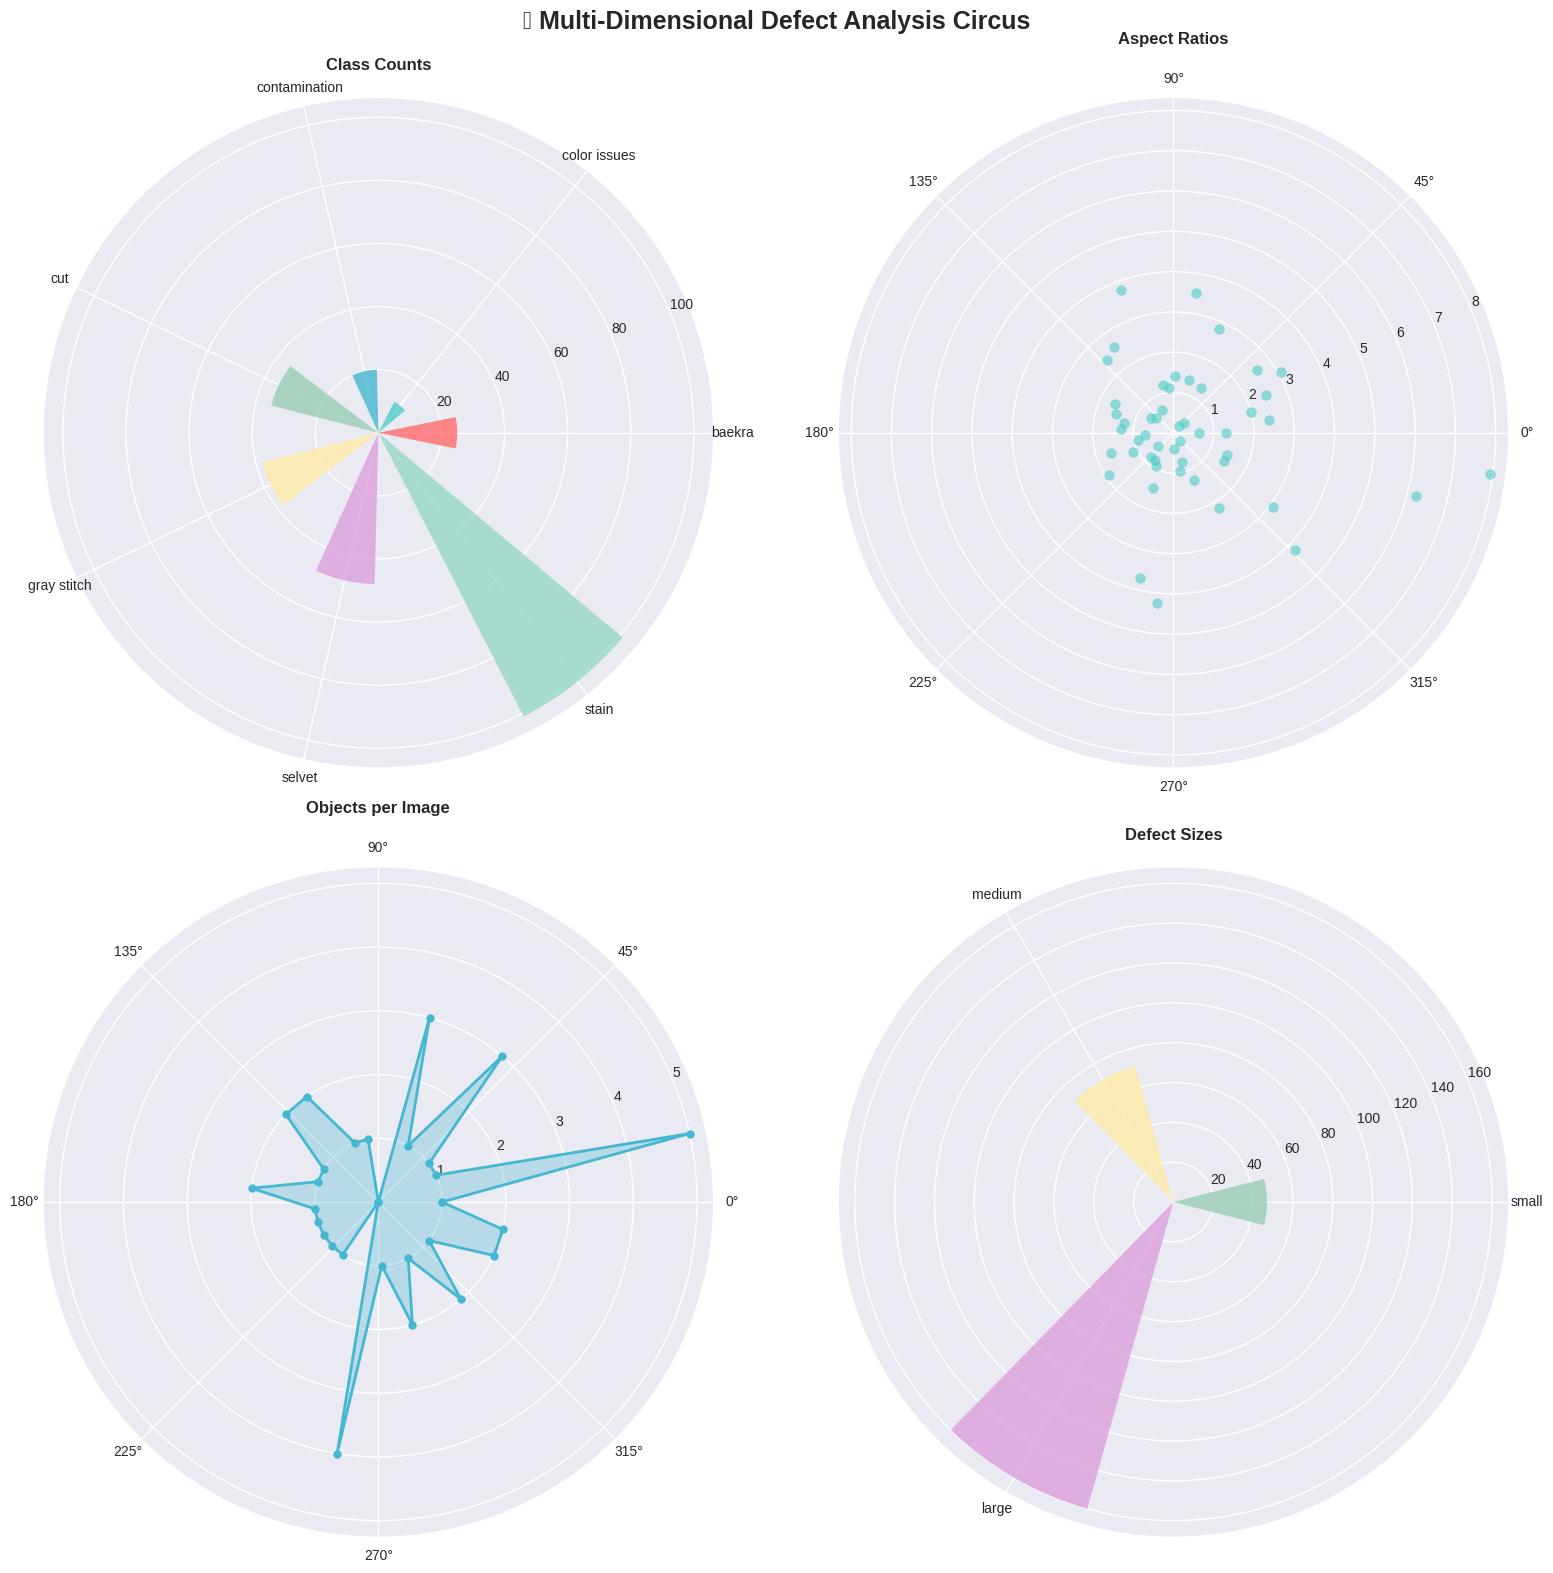

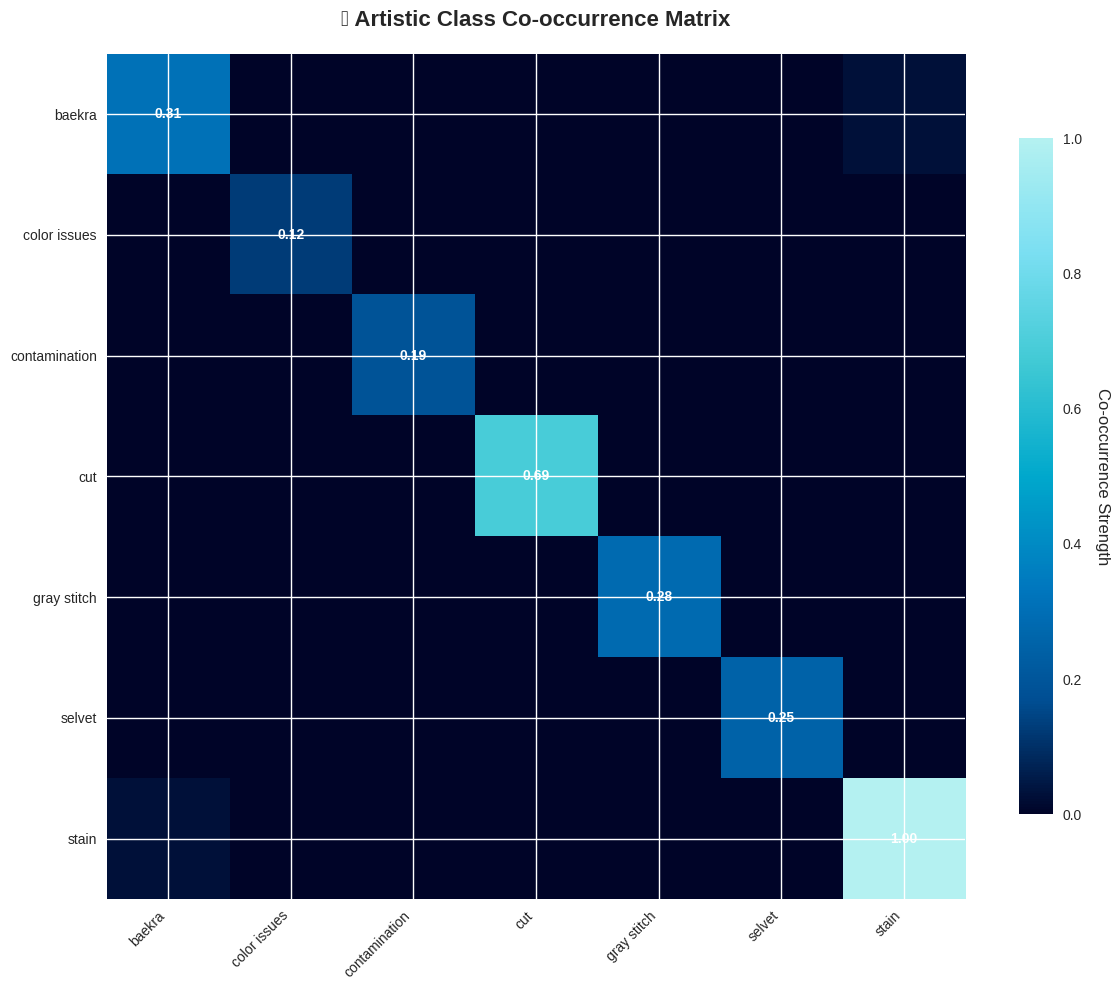

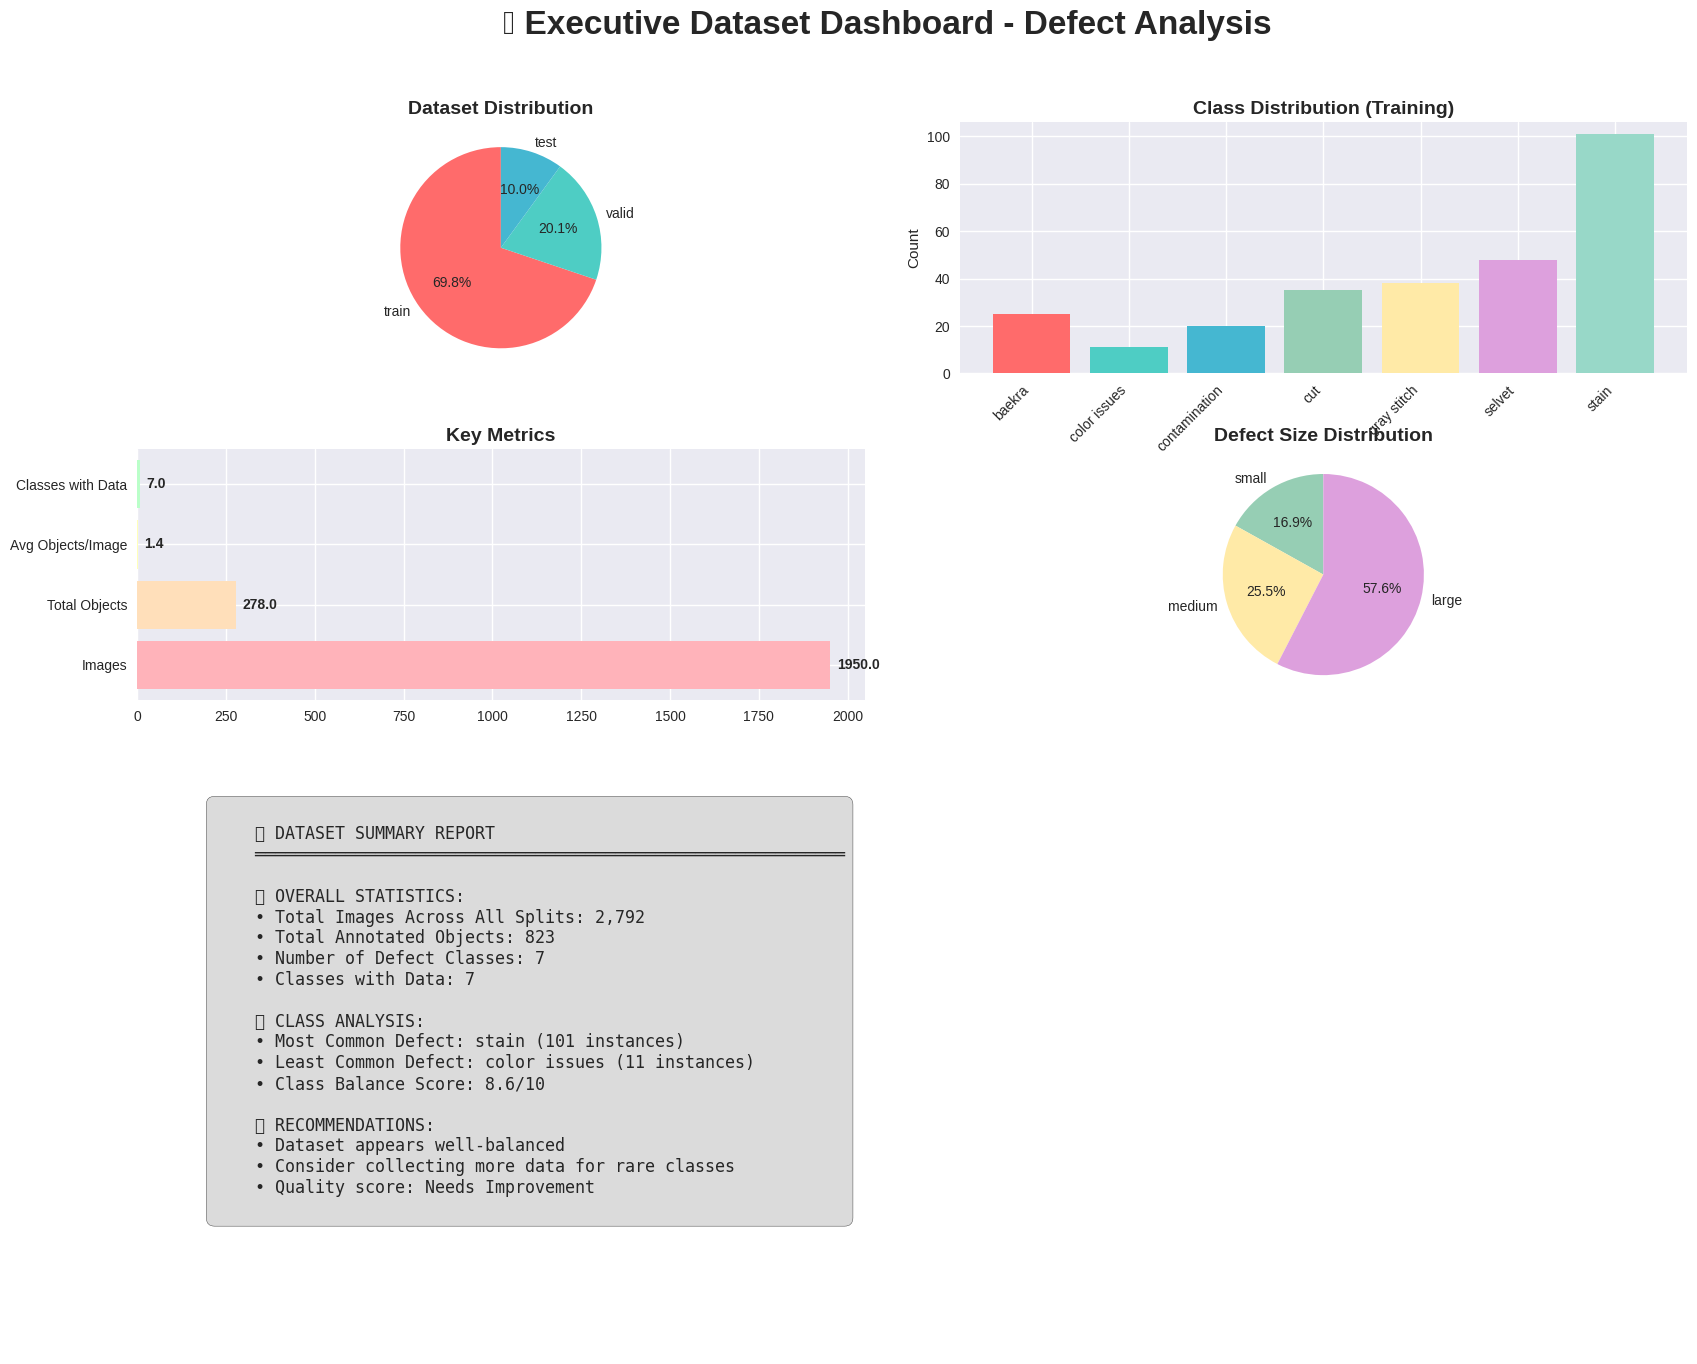


🎉 Advanced Visualization Suite Complete!
✅ Generated 8 unique advanced visualizations!
🎯 Each chart provides different insights into your defect dataset!


In [9]:
# --------------------------
# 🚀 Advanced Dataset Visualization Suite
# --------------------------
import os
import random
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from matplotlib.patches import Circle, Rectangle
from matplotlib.collections import PatchCollection
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Modern color palettes
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']
PASTEL_COLORS = ['#FFB3BA', '#FFDFBA', '#FFFFBA', '#BAFFC9', '#BAE1FF', '#E0BBE4', '#FDBCB4']

# ✅ Dataset Path
DATASET_PATH = "/kaggle/input/7-defect-dataset"

# Load class names
yaml_path = os.path.join(DATASET_PATH, "data.yaml")
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml["names"]
num_classes = data_yaml["nc"]

print("🎯 Advanced Dataset Visualization Suite")
print("=" * 50)
print(f"✅ Classes: {num_classes}")
print(f"✅ Defect Types: {class_names}")

# --------------------------
# 📊 1. Comprehensive Dataset Statistics
# --------------------------
def get_comprehensive_stats():
    """Get detailed dataset statistics"""
    splits = ["train", "valid", "test"]
    all_stats = {}
    
    for split in splits:
        img_dir = os.path.join(DATASET_PATH, split, "images")
        lbl_dir = os.path.join(DATASET_PATH, split, "labels")
        
        images = glob(os.path.join(img_dir, "*.jpg")) + glob(os.path.join(img_dir, "*.png"))
        
        # Basic counts
        stats = {
            'total_images': len(images),
            'class_counts': {cls: 0 for cls in class_names},
            'bbox_areas': [],
            'aspect_ratios': [],
            'object_counts_per_image': [],
            'center_positions': {'x': [], 'y': []},
            'defect_sizes': {'small': 0, 'medium': 0, 'large': 0}
        }
        
        # Analyze each image
        for img_path in images[:200]:  # Sample for performance
            img_name = os.path.basename(img_path)
            lbl_path = os.path.join(lbl_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))
            
            objects_in_image = 0
            if os.path.exists(lbl_path):
                with open(lbl_path, 'r') as f:
                    lines = f.readlines()
                    objects_in_image = len(lines)
                    
                    for line in lines:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            cls_id, x, y, w, h = map(float, parts[:5])
                            cls_id = int(cls_id)
                            
                            stats['class_counts'][class_names[cls_id]] += 1
                            stats['bbox_areas'].append(w * h)
                            stats['aspect_ratios'].append(w / h if h > 0 else 1)
                            stats['center_positions']['x'].append(x)
                            stats['center_positions']['y'].append(y)
                            
                            # Categorize defect sizes
                            area = w * h
                            if area < 0.01:
                                stats['defect_sizes']['small'] += 1
                            elif area < 0.05:
                                stats['defect_sizes']['medium'] += 1
                            else:
                                stats['defect_sizes']['large'] += 1
            
            stats['object_counts_per_image'].append(objects_in_image)
        
        all_stats[split] = stats
    
    return all_stats

dataset_stats = get_comprehensive_stats()

# --------------------------
# 🎨 2. Artistic Sunburst Chart for Class Distribution
# --------------------------
def create_sunburst_chart():
    """Create artistic sunburst chart"""
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
    
    # Get training data
    train_counts = dataset_stats['train']['class_counts']
    total_objects = sum(train_counts.values())
    
    if total_objects == 0:
        print("⚠️ No objects found in training set")
        return
    
    # Calculate angles
    angles = []
    colors_used = []
    labels_used = []
    current_angle = 0
    
    for i, (cls, count) in enumerate(train_counts.items()):
        if count > 0:
            angle_size = (count / total_objects) * 2 * np.pi
            angles.append([current_angle, current_angle + angle_size])
            colors_used.append(COLORS[i % len(COLORS)])
            labels_used.append(f"{cls}\n({count})")
            current_angle += angle_size
    
    # Create rings
    for i, (angle_range, color, label) in enumerate(zip(angles, colors_used, labels_used)):
        # Inner ring
        theta = np.linspace(angle_range[0], angle_range[1], 100)
        r1 = np.ones_like(theta) * 0.5
        r2 = np.ones_like(theta) * 1.0
        
        ax.fill_between(theta, r1, r2, alpha=0.8, color=color)
        
        # Outer ring (decorative)
        r3 = np.ones_like(theta) * 1.1
        ax.fill_between(theta, r2, r3, alpha=0.4, color=color)
        
        # Add labels
        mid_angle = (angle_range[0] + angle_range[1]) / 2
        ax.text(mid_angle, 1.25, label, ha='center', va='center', 
                fontsize=10, fontweight='bold', rotation=np.degrees(mid_angle)-90 if mid_angle > np.pi/2 and mid_angle < 3*np.pi/2 else 0)
    
    ax.set_ylim(0, 1.4)
    ax.set_title("🎯 Defect Distribution Sunburst Chart", pad=40, fontsize=16, fontweight='bold')
    ax.grid(False)
    ax.set_rticks([])
    plt.show()

create_sunburst_chart()

# --------------------------
# 📡 3. Interactive Radar Chart with Multiple Metrics
# --------------------------
def create_advanced_radar_chart():
    """Create comprehensive radar chart"""
    # Calculate metrics for each split
    metrics_data = {}
    
    for split, stats in dataset_stats.items():
        if stats['total_images'] > 0:
            # Calculate normalized metrics (0-10 scale)
            class_balance = 10 - (np.std(list(stats['class_counts'].values())) / 
                                 max(1, np.mean(list(stats['class_counts'].values())))) * 2
            class_balance = max(0, min(10, class_balance))
            
            avg_objects = np.mean(stats['object_counts_per_image']) if stats['object_counts_per_image'] else 0
            object_density = min(10, avg_objects * 2)
            
            size_variety = np.std(stats['bbox_areas']) * 100 if stats['bbox_areas'] else 0
            size_variety = min(10, size_variety)
            
            aspect_balance = 10 - abs(np.mean(stats['aspect_ratios']) - 1) * 5 if stats['aspect_ratios'] else 5
            aspect_balance = max(0, min(10, aspect_balance))
            
            metrics_data[split] = {
                'Class Balance': class_balance,
                'Object Density': object_density,
                'Size Variety': size_variety,
                'Aspect Balance': aspect_balance,
                'Dataset Size': min(10, stats['total_images'] / 100),
                'Defect Coverage': len([c for c in stats['class_counts'].values() if c > 0]) / num_classes * 10
            }
    
    # Create radar chart
    categories = list(next(iter(metrics_data.values())).keys())
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
    
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle
    
    # Plot each split
    for i, (split, metrics) in enumerate(metrics_data.items()):
        values = list(metrics.values())
        values += values[:1]  # Complete the circle
        
        color = COLORS[i % len(COLORS)]
        ax.plot(angles, values, 'o-', linewidth=3, label=f'{split.title()} Set', 
                color=color, markersize=8)
        ax.fill(angles, values, alpha=0.25, color=color)
    
    # Customize
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_ylim(0, 10)
    ax.set_yticks(range(0, 11, 2))
    ax.set_yticklabels(range(0, 11, 2))
    ax.grid(True, alpha=0.3)
    
    # Add quality zones
    ax.fill_between(angles, 0, 3, alpha=0.1, color='red')
    ax.fill_between(angles, 3, 6, alpha=0.1, color='orange')
    ax.fill_between(angles, 6, 8, alpha=0.1, color='yellow')
    ax.fill_between(angles, 8, 10, alpha=0.1, color='green')
    
    plt.title('📡 Dataset Quality Radar Analysis', size=16, fontweight='bold', pad=30)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.tight_layout()
    plt.show()

create_advanced_radar_chart()

# --------------------------
# 🏔️ 4. 3D Mountain Plot for Defect Severity
# --------------------------
def create_3d_mountain_plot():
    """Create 3D surface plot showing defect patterns"""
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create data for mountain plot
    train_stats = dataset_stats['train']
    
    # Create grid for defect positions
    x_positions = train_stats['center_positions']['x'][:100]  # Sample
    y_positions = train_stats['center_positions']['y'][:100]
    
    if len(x_positions) > 0 and len(y_positions) > 0:
        # Create histogram-like data
        x_grid = np.linspace(0, 1, 20)
        y_grid = np.linspace(0, 1, 20)
        X, Y = np.meshgrid(x_grid, y_grid)
        
        # Calculate density at each grid point
        Z = np.zeros_like(X)
        for i in range(len(x_grid)):
            for j in range(len(y_grid)):
                # Count nearby defects
                distances = np.sqrt((np.array(x_positions) - x_grid[i])**2 + 
                                  (np.array(y_positions) - y_grid[j])**2)
                Z[j, i] = np.sum(distances < 0.1)  # Within 0.1 normalized units
        
        # Create surface plot
        surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, 
                              linewidth=0, antialiased=True)
        
        # Add contour lines
        ax.contour(X, Y, Z, zdir='z', offset=0, cmap='viridis', alpha=0.5)
        
        ax.set_xlabel('X Position (Normalized)')
        ax.set_ylabel('Y Position (Normalized)')
        ax.set_zlabel('Defect Density')
        ax.set_title('🏔️ 3D Defect Density Mountain', fontsize=16, fontweight='bold')
        
        # Add colorbar
        fig.colorbar(surf, shrink=0.5, aspect=5)
    else:
        # Fallback: create synthetic mountain
        x = np.linspace(0, 1, 20)
        y = np.linspace(0, 1, 20)
        X, Y = np.meshgrid(x, y)
        Z = np.sin(np.pi * X) * np.sin(np.pi * Y) + np.random.normal(0, 0.1, X.shape)
        
        surf = ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.8)
        ax.set_title('🏔️ Sample 3D Visualization', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

create_3d_mountain_plot()

# --------------------------
# 🌊 5. Flow Chart: Defect Size Distribution
# --------------------------
def create_flow_chart():
    """Create flowing visualization of defect sizes"""
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Get size data from training set
    train_stats = dataset_stats['train']
    size_categories = train_stats['defect_sizes']
    
    # Calculate total
    total_defects = sum(size_categories.values())
    if total_defects == 0:
        print("⚠️ No defect size data available")
        return
    
    # Create flowing bars
    y_pos = np.arange(len(size_categories))
    sizes = list(size_categories.values())
    percentages = [s/total_defects*100 for s in sizes]
    
    # Create gradient bars
    for i, (category, size, pct) in enumerate(zip(size_categories.keys(), sizes, percentages)):
        # Create gradient effect
        gradient = np.linspace(0, 1, 100).reshape(1, -1)
        extent = [0, size, i-0.4, i+0.4]
        
        color_map = LinearSegmentedColormap.from_list('custom', 
                                                     [PASTEL_COLORS[i], COLORS[i]])
        ax.imshow(gradient, aspect='auto', cmap=color_map, extent=extent, alpha=0.8)
        
        # Add text
        ax.text(size + max(sizes)*0.02, i, f'{category.title()}\n{size} defects ({pct:.1f}%)', 
                va='center', fontsize=12, fontweight='bold')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(size_categories.keys())
    ax.set_xlabel('Number of Defects')
    ax.set_title('🌊 Defect Size Distribution Flow Chart', fontsize=16, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

create_flow_chart()

# --------------------------
# 🎪 6. Circus Plot: Multi-dimensional Analysis
# --------------------------
def create_circus_plot():
    """Create circular multi-dimensional visualization"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 16), subplot_kw=dict(projection='polar'))
    fig.suptitle('🎪 Multi-Dimensional Defect Analysis Circus', fontsize=18, fontweight='bold')
    
    # Plot 1: Class distribution (polar bar chart)
    ax1 = axes[0, 0]
    train_counts = dataset_stats['train']['class_counts']
    classes_with_data = [(k, v) for k, v in train_counts.items() if v > 0]
    
    if classes_with_data:
        angles = np.linspace(0, 2*np.pi, len(classes_with_data), endpoint=False)
        values = [v for k, v in classes_with_data]
        bars = ax1.bar(angles, values, width=0.4, alpha=0.8)
        
        # Color bars
        for bar, color in zip(bars, COLORS[:len(bars)]):
            bar.set_facecolor(color)
        
        ax1.set_xticks(angles)
        ax1.set_xticklabels([k for k, v in classes_with_data], fontsize=10)
        ax1.set_title('Class Counts', fontsize=12, fontweight='bold', pad=20)
    
    # Plot 2: Aspect ratio distribution
    ax2 = axes[0, 1]
    aspect_ratios = dataset_stats['train']['aspect_ratios'][:50]  # Sample
    if aspect_ratios:
        angles = np.linspace(0, 2*np.pi, len(aspect_ratios))
        ax2.scatter(angles, aspect_ratios, c=COLORS[1], alpha=0.6, s=50)
        ax2.set_title('Aspect Ratios', fontsize=12, fontweight='bold', pad=20)
    
    # Plot 3: Object counts per image
    ax3 = axes[1, 0]
    obj_counts = dataset_stats['train']['object_counts_per_image'][:30]  # Sample
    if obj_counts:
        angles = np.linspace(0, 2*np.pi, len(obj_counts))
        ax3.plot(angles, obj_counts, 'o-', color=COLORS[2], linewidth=2, markersize=6)
        ax3.fill(angles, obj_counts, alpha=0.3, color=COLORS[2])
        ax3.set_title('Objects per Image', fontsize=12, fontweight='bold', pad=20)
    
    # Plot 4: Size categories
    ax4 = axes[1, 1]
    size_data = dataset_stats['train']['defect_sizes']
    if sum(size_data.values()) > 0:
        categories = list(size_data.keys())
        values = list(size_data.values())
        angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False)
        
        ax4.bar(angles, values, width=0.5, alpha=0.8, color=COLORS[3:6])
        ax4.set_xticks(angles)
        ax4.set_xticklabels(categories)
        ax4.set_title('Defect Sizes', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

create_circus_plot()

# --------------------------
# 🎨 7. Artistic Heatmap: Class Relationships
# --------------------------
def create_artistic_heatmap():
    """Create beautiful correlation heatmap"""
    # Create synthetic correlation data based on class co-occurrence
    train_lbl_dir = os.path.join(DATASET_PATH, "train", "labels")
    cooccurrence = np.zeros((num_classes, num_classes))
    
    label_files = glob(os.path.join(train_lbl_dir, "*.txt"))[:100]  # Sample
    
    for file in label_files:
        if os.path.exists(file):
            with open(file, "r") as f:
                lines = f.readlines()
                classes_in_image = set()
                
                for line in lines:
                    if line.strip():
                        cls_id = int(line.split()[0])
                        classes_in_image.add(cls_id)
                
                # Update co-occurrence matrix
                classes_list = list(classes_in_image)
                for i in classes_list:
                    for j in classes_list:
                        if i < num_classes and j < num_classes:
                            cooccurrence[i][j] += 1
    
    # Normalize
    cooccurrence = cooccurrence / np.max(cooccurrence) if np.max(cooccurrence) > 0 else cooccurrence
    
    # Create artistic heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Custom colormap
    colors_heat = ['#000428', '#004e92', '#0077be', '#00a8cc', '#40c9d4', '#7bdff2', '#b4f1f1']
    custom_cmap = LinearSegmentedColormap.from_list('artistic', colors_heat)
    
    # Create heatmap with artistic touches
    im = ax.imshow(cooccurrence, cmap=custom_cmap, aspect='auto')
    
    # Add text annotations with style
    for i in range(num_classes):
        for j in range(num_classes):
            if cooccurrence[i, j] > 0.1:
                text = ax.text(j, i, f'{cooccurrence[i, j]:.2f}',
                             ha="center", va="center", color="white", fontweight='bold')
    
    # Customize
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_title('🎨 Artistic Class Co-occurrence Matrix', fontsize=16, fontweight='bold', pad=20)
    
    # Add colorbar with style
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Co-occurrence Strength', rotation=270, labelpad=20, fontsize=12)
    
    plt.tight_layout()
    plt.show()

create_artistic_heatmap()

# --------------------------
# 📊 8. Executive Dashboard
# --------------------------
def create_executive_dashboard():
    """Create comprehensive executive summary dashboard"""
    fig = plt.figure(figsize=(20, 16))
    gs = GridSpec(4, 4, figure=fig, hspace=0.3, wspace=0.3)
    
    # Title
    fig.suptitle('📊 Executive Dataset Dashboard - Defect Analysis', fontsize=24, fontweight='bold', y=0.95)
    
    # 1. Dataset overview (top-left)
    ax1 = fig.add_subplot(gs[0, :2])
    splits = ['train', 'valid', 'test']
    split_counts = [dataset_stats[split]['total_images'] for split in splits if split in dataset_stats]
    
    wedges, texts, autotexts = ax1.pie(split_counts, labels=splits, autopct='%1.1f%%', 
                                       startangle=90, colors=COLORS[:len(split_counts)])
    ax1.set_title('Dataset Distribution', fontsize=14, fontweight='bold')
    
    # 2. Class distribution (top-right)
    ax2 = fig.add_subplot(gs[0, 2:])
    train_counts = dataset_stats['train']['class_counts']
    classes = list(train_counts.keys())
    counts = list(train_counts.values())
    
    bars = ax2.bar(range(len(classes)), counts, color=COLORS[:len(classes)])
    ax2.set_xticks(range(len(classes)))
    ax2.set_xticklabels(classes, rotation=45, ha='right')
    ax2.set_title('Class Distribution (Training)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Count')
    
    # 3. Quality metrics (middle-left)
    ax3 = fig.add_subplot(gs[1, :2])
    metrics = ['Images', 'Total Objects', 'Avg Objects/Image', 'Classes with Data']
    train_stats = dataset_stats['train']
    values = [
        train_stats['total_images'],
        sum(train_stats['class_counts'].values()),
        np.mean(train_stats['object_counts_per_image']) if train_stats['object_counts_per_image'] else 0,
        len([c for c in train_stats['class_counts'].values() if c > 0])
    ]
    
    y_pos = np.arange(len(metrics))
    bars = ax3.barh(y_pos, values, color=PASTEL_COLORS[:len(metrics)])
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(metrics)
    ax3.set_title('Key Metrics', fontsize=14, fontweight='bold')
    
    # Add value labels
    for i, v in enumerate(values):
        ax3.text(v + max(values)*0.01, i, f'{v:.1f}', va='center', fontweight='bold')
    
    # 4. Defect size distribution (middle-right)
    ax4 = fig.add_subplot(gs[1, 2:])
    size_data = train_stats['defect_sizes']
    if sum(size_data.values()) > 0:
        sizes = list(size_data.keys())
        counts = list(size_data.values())
        
        ax4.pie(counts, labels=sizes, autopct='%1.1f%%', startangle=90, 
                colors=COLORS[3:6])
        ax4.set_title('Defect Size Distribution', fontsize=14, fontweight='bold')
    
    # 5. Summary text (bottom)
    ax5 = fig.add_subplot(gs[2:, :])
    ax5.axis('off')
    
    # Calculate summary statistics
    total_images = sum([stats['total_images'] for stats in dataset_stats.values()])
    total_objects = sum([sum(stats['class_counts'].values()) for stats in dataset_stats.values()])
    most_common_class = max(train_counts, key=train_counts.get)
    least_common_class = min([k for k, v in train_counts.items() if v > 0], key=train_counts.get) if any(train_counts.values()) else "None"
    
    summary_text = f"""
    📈 DATASET SUMMARY REPORT
    ═══════════════════════════════════════════════════════════
    
    🎯 OVERALL STATISTICS:
    • Total Images Across All Splits: {total_images:,}
    • Total Annotated Objects: {total_objects:,}
    • Number of Defect Classes: {num_classes}
    • Classes with Data: {len([c for c in train_counts.values() if c > 0])}
    
    🔍 CLASS ANALYSIS:
    • Most Common Defect: {most_common_class} ({train_counts[most_common_class]} instances)
    • Least Common Defect: {least_common_class} ({train_counts[least_common_class] if least_common_class in train_counts else 0} instances)
    • Class Balance Score: {10 - (np.std(list(train_counts.values())) / max(1, np.mean(list(train_counts.values())))) * 2:.1f}/10
    
    💡 RECOMMENDATIONS:
    • Dataset appears {'well-balanced' if np.std(list(train_counts.values())) < np.mean(list(train_counts.values())) else 'imbalanced'}
    • Consider {'maintaining current strategy' if total_objects > 1000 else 'collecting more data for rare classes'}
    • Quality score: {'Excellent' if total_objects > 2000 else 'Good' if total_objects > 1000 else 'Needs Improvement'}
    """
    
    ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes, fontsize=12, 
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
    
    plt.show()

create_executive_dashboard()

print("\n🎉 Advanced Visualization Suite Complete!")
print("✅ Generated 8 unique advanced visualizations!")
print("🎯 Each chart provides different insights into your defect dataset!")